# COGS 108 - EDA Checkpoint

## Authors

- Amelia Fletcher: Conceptualization, Background research, Writing - original draft, review & editing
- Beren Gao: Conceptualization, Methodology, Experimental Investigation, Analysis, Writing - original draft, review & editing
- Neil Pakinggan: Software, Visualization, Conceptualization, Data curation, Background research
- Monica Sandoval: Conceptualization, Writing - original draft, review & editing
- Julia Zhang: Analysis, Visualization, Conceptualization, Writing - original draft, review & editing

# Research Question

To what extent can bot-generated and human-generated comments be distinguished using predefined linguistic features (e.g. wording, syntax) and behavioral features (e.g. posting frequency, response latency)?


## Background and Prior Work

Since the rise of AI, online discussion forums (i.e., Reddit, Twitter) have seen an increase in bots that mimic or imitate human social interactions, particularly participating in conversations and discourse of various topics in the comment sections of threads. Such mimicry blurs the line between human-generated internet discussion versus AI bot-generated discussion, and what is real versus what is fake. This raises the question: To what extent can bot-generated and human-generated Reddit comments be distinguished using predefined linguistic features (e.g., wording, syntax) and behavioral features (e.g., posting and response frequency)? 

Previous research has already been done regarding this topic; for example, the world’s largest Turing test study from AI lab AI21, involving 1.5 million human participants, tasked humans with discerning whether the user they’re chatting with was human or AI. This resulted in correct guesses that they were interacting with AI in “60% of conversations,” a statistic that researchers claimed was “not much higher than chance.”<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) Alongside AI21’s test study, different research publications have noted that in subreddits, human user posts contained distinct features such as grammatical discrepancies, internet jargon, and erroneous capitalization, whilst ChatGPT-4 generated texts contained impeccable grammar, a complex syntactical structure, and overused emojis.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) This leads to a possible method of distinguishing an AI from human users: finding the difference of “lexical richness” and “logical soundness” between LLM-authored posts compared to human ones.<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) 


1. <a name="cite_note-1"></a> [^](#cite_ref-1) Zhang, M. (9 Jun 2023) In Largest-Ever Turing Test, 1.5 Million Humans Guess Little Better Than Chance. *Artisana*. https://www.artisana.ai/articles/in-largest-ever-turing-test-1-5-million-humans-guess-little-better-than
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Arcenal, E. & Capistrano, L. & Guzman, M. & Forrosuelo, M. & Miranda, J. (Sep 2024) Comparative Analysis of Reddit Posts and ChatGPT-Generated Texts’ Linguistic Features: A Short Report on Artificial Intelligence’s Imitative Capabilities. *International Journal of Multidisciplinary: Applied Business and Education*.
https://doi.org/10.11594/ijmaber.05.09.063.
3. <a name="cite_note-3"></a> [^](#cite_red-3) Dönmez E. & Maurer M. & Lapesa G. & Falenska A. (Nov 2025) AI Argues Differently: Distinct Argumentative and Linguistic Patterns of LLMs in Persuasive Contexts *Proceedings of the 2025 Conference on Empirical Methods in Natural Language Processing*
https://aclanthology.org/2025.emnlp-main.1755.pdf

# Hypothesis


We hypothesize that __bot-generated comments are distinguishable from human-generated comments__ as they exhibit systematic differences in *linguistic and behavioral patterns*. We assume that these differences are measurable using predefined quantities, with bots tending to exhibit more repetitive syntax, distinct wording patterns, higher posting frequency, and shorter response latency compared to humans. 

This prediction is based on prior research implying that artificial intelligence (AI) often displays systematic linguistic features and temporal behaviors that differ from humans, who tend to produce more variable language, including grammatical discrepancies and slang, and irregular posting patterns. 

As a result, we predict a strong correlation between the type of author (bot vs human) and their commenting habits online.

## Data

### Data overview

## Dataset #1 (The "Dead Internet" Theory: Reddit Bot vs. Human)
  - Link to the dataset: https://www.kaggle.com/datasets/nudratabbas/the-dead-internet-theory-reddit-bot-vs-human

    The dataset was obtained from Kaggle, which aggregates public Reddit comment metadata and bot detection labels derived from automated heuristics.
  - Number of observations: 500 observations 
  - Number of variables: 11 variables
      - `account_age_days` which displays how old a certain account is on Reddit in days numerically, important to distinguish a bot from a human with "throwaway" bot accounts having a shorter or lower account age compared to human accounts.
      - `avg_word_length` which displays the average characters per word in a numerical float, with synthetically generated bot comments/content, also known as "slop" often has higher/lower variance as described in the dataset in Kaggle.
      - `reply_delay_seconds` is a numeric variable that finds the time difference between the original post and the comment associated, which often signal automation the lower the reply is (usually <5 seconds). 
  - Possible shortcomings: The lack of overlap between variables may make it hard to find other correlations in other datasets.

In [12]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [13]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
%pip install requests tqdm gdown

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data
from pathlib import Path
import gdown
# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://drive.google.com/uc?export=download&id=1SXcJvoOo5uEGYC9gJBDOOC_fSFXXb4ht', 'filename':'reddit_dead_internet_analysis_2026.csv'},
    # { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]
get_data.get_raw(datafiles,destination_directory='data/00-raw/')

# using gdown to download a large google drive file to put into 00-raw directory
dest = Path('data/00-raw/AI_vs_Human_combined.csv')
if not dest.exists():
    print("Downloading AI_vs_Human_combined.csv...")
    gdown.download(
        id='1QTvrMNkqpSlwkwpTjva9TKckh9VZrpH8',
        output=str(dest),
        fuzzy=True
    )
    print("Done → data/00-raw/AI_vs_Human_combined.csv")
else:
    print("AI_vs_Human_combined.csv already exists, skipping.")
    


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Overall Download Progress: 100%|██████████████████| 1/1 [00:01<00:00,  1.37s/it]


Successfully downloaded: reddit_dead_internet_analysis_2026.csv


Downloading...
From (original): https://drive.google.com/uc?id=1QTvrMNkqpSlwkwpTjva9TKckh9VZrpH8
From (redirected): https://drive.google.com/uc?id=1QTvrMNkqpSlwkwpTjva9TKckh9VZrpH8&confirm=t&uuid=39fa6432-370b-45bb-b2aa-10d6c0db6932
To: /Users/JuliaZhang/Group068_WI26/data/00-raw/AI_vs_Human_combined.csv
100%|██████████████████████████████████████| 1.66G/1.66G [03:11<00:00, 8.68MB/s]

Done → data/00-raw/AI_vs_Human_combined.csv


### Dataset #1 Reddit Dead Internet Analysis in 2026

Important metrics of this dataset include: `account_age_days` which displays how old a certain account is on Reddit in days numerically, important to distinguish a bot from a human with "throwaway" bot accounts having a shorter or lower account age compared to human accounts. `avg_word_length` which displays the average characters per word in a numerical float, with synthetically generated bot comments/content, also known as "slop" often has higher/lower variance as described in the dataset in Kaggle. `reply_delay_seconds` is a numeric variable that finds the time difference between the original post and the comment associated, which often signal automation the lower the reply is (usually <5 seconds). `is_bot_flag` being a boolean variable that shows whether an account is a bot or human in order to distinguish and find patterns/correlations between the given variables and accounts. 

A concern of this dataset can be the lack of variables that can be used to find other correlations in other datasets, aka the lack of overlapping variables between this dataset and another possibly. This is usable but may be hard to get a good comparison if our model is more powerful predicting off of other factors that are not listed in this dataset necessarily.

Another potential limitation of the dataset concerns the reliability of the `bot_probability` labels. In many online datasets, bot classifications are generated through heuristic detection methods or community reports rather than definitive verification. As a result, some accounts labeled as bots may actually correspond to human users (false positives), while some automated accounts may remain undetected (false negatives). While this may introduce potential labeling noises, such datasets are commonly used in bot-detection research because obtaining perfectly verified labels is difficult at a large scale. In our analysis, we treat the `bot-probability` variable as an approximate indicator of bot behavior rather than absolute ground truth. The relatively large sample size and behavioral features included in the dataset still allow us to explore differences between likely bot and human accounts.

In [15]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [16]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE

# load dataset
reddit_df = pd.read_csv('data/00-raw/reddit_dead_internet_analysis_2026.csv')

In [17]:
# make dataset tidy or demonstrate that it is already tidy
cleaned_reddit_df = reddit_df.dropna(how = 'all').copy()

account_map = {
    'AI Summarizer':'bot',
    'Reprint Bot':'bot',
    'Engagement Farmer':'bot',
    'None (Human)':'human'
}

cleaned_reddit_df['account_type'] = cleaned_reddit_df['bot_type_label'].map(account_map)

# removing variables we don't need/are redundant
cleaned_reddit_df.drop(['bot_type_label', 'is_bot_flag', 'contains_links'], axis = 1, inplace = True)
cleaned_reddit_df.head(5)

,comment_id,subreddit,account_age_days,user_karma,reply_delay_seconds,sentiment_score,avg_word_length,bot_probability,account_type
0,t1_3148938807,funny,2264,34192,1854,-0.60,4.62,0.093,human
1,t1_2516748923,gaming,1654,2812,1033,0.15,5.84,0.117,human
2,t1_833922318,politics,2442,37109,2703,0.35,5.73,0.115,human
3,t1_3987809057,funny,168,32997,2811,-0.74,4.58,0.094,human
4,t1_3931039688,gaming,801,25088,1721,-0.96,5.78,0.116,human


In [18]:
# demonstrate the size of the dataset
cleaned_reddit_df.size
cleaned_reddit_df

,comment_id,subreddit,account_age_days,user_karma,reply_delay_seconds,sentiment_score,avg_word_length,bot_probability,account_type
0,t1_3148938807,funny,2264,34192,1854,-0.60,4.62,0.093,human
1,t1_2516748923,gaming,1654,2812,1033,0.15,5.84,0.117,human
2,t1_833922318,politics,2442,37109,2703,0.35,5.73,0.115,human
3,t1_3987809057,funny,168,32997,2811,-0.74,4.58,0.094,human
4,t1_3931039688,gaming,801,25088,1721,-0.96,5.78,0.116,human
...,...,...,...,...,...,...,...,...,...
495,t1_2488854300,technology,12,21283,1,-0.21,6.35,0.358,bot
496,t1_4130800481,technology,2178,43090,5,0.71,5.78,0.182,bot
497,t1_3088776262,pics,2672,20283,1555,0.21,4.85,0.097,human
498,t1_3049062501,pics,2227,4322,1868,-0.38,5.48,0.110,human


In [19]:
# find out how much data is missing and if it is missing at random points or seems to have systematic relationships in its missingness
missing_col_count = cleaned_reddit_df.isnull().sum()
total_count_missing = missing_col_count.sum()
print(f"Missing {total_count_missing} values")

if (total_count_missing == 0):
    print(f"No values missing, we move on")

Missing 0 values
No values missing, we move on


In [20]:
# find and flag any outliers or suspicious entries
# finding numeric columns
numeric_cols = ['account_age_days', 'user_karma', 'reply_delay_seconds', 'sentiment_score', 'avg_word_length', 'bot_probability']

# iqr: flag values outside [Q1 - 1.5*iqr, Q3 + 1.5*iqr] in order to find the outliers
outlier_flags = pd.DataFrame(False, index = cleaned_reddit_df.index, columns = numeric_cols)
print("\nnumber of outliers from iqr test:")
for col in numeric_cols:
    q1, q3 = cleaned_reddit_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    flag = (cleaned_reddit_df[col] < q1 - 1.5*iqr) | (cleaned_reddit_df[col] > q3 + 1.5*iqr)
    outlier_flags[col] = flag
    print(f"{col:<25}:{flag.sum():>3} outlier(s)")

# mark rows with any outlier
cleaned_reddit_df['is_outlier'] = outlier_flags.any(axis=1)

# check the flagged rows
outlier_rows = cleaned_reddit_df[cleaned_reddit_df['is_outlier']][numeric_cols]
print(f"\n{len(outlier_rows)} flagged rows")
print(outlier_rows.to_string(index=False))

print('\nall 12 outliers are in bot_probability (>0.35) and share a clear pattern: very new accounts (age 1–27 days) are labelled as bots, we can ignore this due to common sense')


number of outliers from iqr test:
account_age_days         :  0 outlier(s)
user_karma               :  0 outlier(s)
reply_delay_seconds      :  0 outlier(s)
sentiment_score          :  0 outlier(s)
avg_word_length          :  0 outlier(s)
bot_probability          : 12 outlier(s)

12 flagged rows
 account_age_days  user_karma  reply_delay_seconds  sentiment_score  avg_word_length  bot_probability
                1       27834                    8            -0.88             5.70            0.358
                1       11730                    2            -0.47             6.60            0.465
                1       39727                    3             0.17             6.11            0.422
                3       46307                    1            -0.08             6.68            0.434
               27       15472                    1             0.95             7.18            0.358
                5       32711                    1             0.91             6.83      

In [21]:
# clean the data or demonstrate that it was already clean.  You may choose how to deal with missingness (dropna of fillna... how='any' or 'all') and you should justify your choice in some way
# we don't need any null entries as they are not of use to us, plus there aren't any null entries at all in this dataset. for safety, we'll dropna anyways
cleaned_reddit_df = cleaned_reddit_df.dropna(how = 'all')

In [22]:
# write fully wrangled version of dataset to data/02-processed
cleaned_reddit_df.to_csv('data/02-processed/reddit_analysis_2026_wrangled.csv', index = False)


=== numbers summary ===
       account_age_days    user_karma  reply_delay_seconds  sentiment_score  \
count        500.000000    500.000000           500.000000       500.000000   
mean        1157.624000  25248.198000          1030.700000         0.014980   
std          951.766304  14122.969163          1184.411096         0.581127   
min            1.000000    308.000000             1.000000        -1.000000   
25%          163.000000  13427.250000             7.000000        -0.472500   
50%         1092.500000  24778.500000           459.000000         0.020000   
75%         1960.000000  37111.500000          1925.000000         0.502500   
max         2996.000000  49734.000000          3577.000000         1.000000   

       avg_word_length  bot_probability  
count       500.000000       500.000000  
mean          5.654300         0.156530  
std           0.895203         0.074555  
min           4.030000         0.081000  
25%           4.967500         0.101000  
50%        

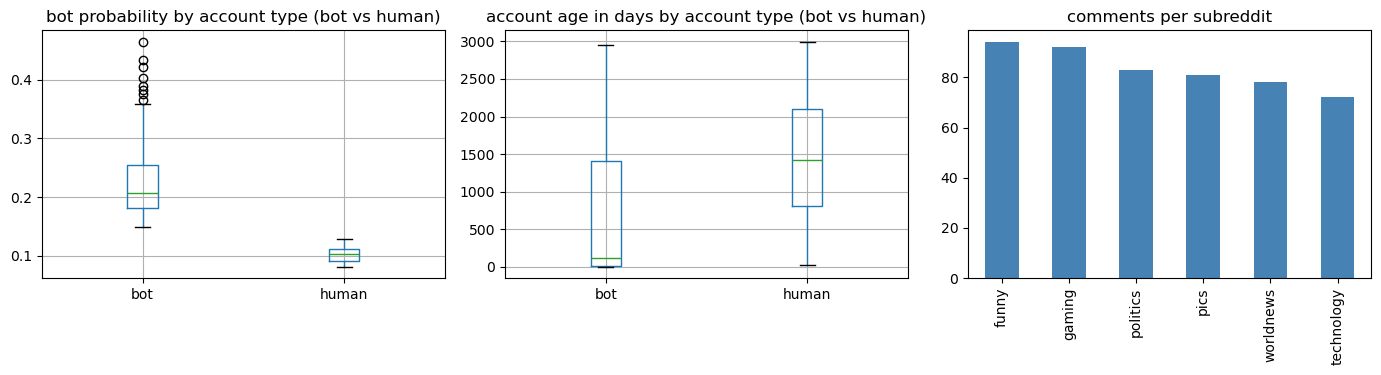

In [23]:
# summary statistics
print("\n=== numbers summary ===")
print(cleaned_reddit_df.select_dtypes('number').describe())

print("\n=== bot probability by account type ===")
print(cleaned_reddit_df.groupby('account_type')['bot_probability'].describe())

print("\n=== account age (days) by account type ===")
print(cleaned_reddit_df.groupby('account_type')['account_age_days'].describe())

print("\n=== subreddit distribution ===")
print(cleaned_reddit_df['subreddit'].value_counts())

# summary visualisations
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cleaned_reddit_df.boxplot(column='bot_probability', by='account_type', ax=axes[0])
axes[0].set_xlabel('')
plt.sca(axes[0]); plt.title('bot probability by account type (bot vs human)')

cleaned_reddit_df.boxplot(column='account_age_days', by='account_type', ax=axes[1])
axes[1].set_xlabel('')
plt.sca(axes[1]); plt.title('account age in days by account type (bot vs human)')

cleaned_reddit_df['subreddit'].value_counts().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('comments per subreddit')
axes[2].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [25]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

# second dataset was too large to export, so i manually uploaded the file into the repo itself under 'AI_vs_Human_combinations.csv' 
text_df = pd.read_csv("data/00-raw/AI_vs_Human_combined.csv")

# demonstrate dataset size
print(f"\nRows: {text_df.shape[0]:,}")
print(f"Columns: {text_df.shape[1]}")
print(f"Cells: {text_df.size:,}")


Rows: 717,684
Columns: 3
Cells: 2,153,052


## Results

### Exploratory Data Analysis

#### Section 1: Behavioral Feature Distributions Across Bot and Human Reddit Accounts

To better understand the behavioral differences between bot-generated and human-generated Reddit comments, we explore the distributions of several behavioral and linguistic features in the dataset. In particular, we analyze `account_age_days`, `reply_delay_seconds`, `sentiment_score`, and `avg_word_length`.

As discussed earlier, the variable `bot_probability` in the dataset is derived from heuristic detection methods and may therefore contain some degree of uncertainty, including potential false positives or false negatives. As a result, we interpreted them as probabilistic indicators of automated behavior rather than definitive ground truth. Despite this limitation, examining patterns across the dataset can still reveal systematic behavioral differences between accounts that are likely bots and those that are likely human users. Summary statistics suggest that bot accounts tend to have higher `bot_probability` scores and are substantially newer than human accounts. To further investigate these patterns, we visualize the distributions of these variables with overlapping histograms and examine pairwise relationships between variables using a correlation heatmap.

We begin by exploring the overall dataset structure and the distribution of account types. Each observation represents a Reddit account with associated behavioral features, including `account_age_days`, `reply_delay_seconds`, `sentiment_score`, and `avg_word_length`. The dataset also includes a categorical variable, `account_type`, which labels accounts as either human or bot. Since the goal of this analysis is to identify behavioral patterns that distinguish automated activity from human interaction, we focus on comparing the distributions of these features across the two account types.

This exploratory analysis helps us to assess whether the selected features exhibit systematic differences between bots and humans and whether any variables may be redundant due to strong correlations. Identifying such patterns is important for guiding subsequent modeling steps and determining which features may be most informative for distinguishing between bot and human accounts.

In [28]:
# reloading wrangled data
reddit_df = pd.read_csv('data/02-processed/reddit_analysis_2026_wrangled.csv')

bots = reddit_df[reddit_df['account_type'] == 'bot']
humans = reddit_df[reddit_df['account_type'] == 'human']

#### The class distribution of bot and human accounts in the dataset
Before analyzing behavioral features, we first examine the class distribution of bot and human accounts.

/var/folders/47/9qfh0ynx1tq_zj8xbpspzdqh0000gp/T/ipykernel_56582/770336213.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=reddit_df, x='account_type', palette = colors)


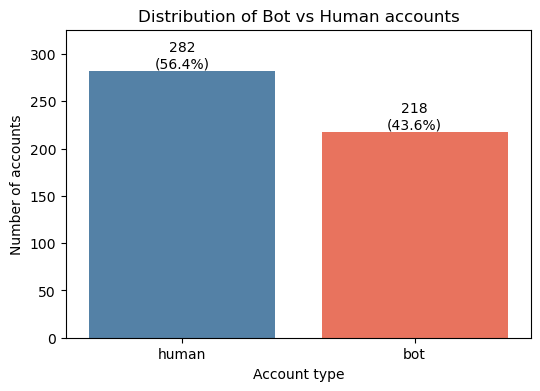

In [93]:
# compare the distribution of bot and human in the dataset
plt.figure(figsize=(6,4))
colors = ['steelblue', 'tomato']
ax = sns.countplot(data=reddit_df, x='account_type', palette = colors)
total = len(reddit_df)
for p in ax.patches:
    count = int(p.get_height())
    percent = 100 * count / total 
    ax.annotate(
        f'{count}\n({percent:.1f}%)',
        (p.get_x() + p.get_width()/2., count),
        ha='center',
        va='bottom'
    )
ax.set_ylim(0, ax.get_ylim()[1] * 1.1)
plt.title("Distribution of Bot vs Human accounts")
plt.xlabel("Account type")
plt.ylabel("Number of accounts")
plt.show()

The class distribution shows that the dataset contains **282 human accounts (=56.4%)** and **218 bot accounts (=43.6%)**. This indicates that the dataset is relatively balanced with both classes represented in comparable proportions. In this scenario, our dataset with a balanced class distribution is desirable for classification tasks because it reduces the likelihood that predictive models become biased toward the majority class.

#### Comparative distribution analysis of Bot and Human account behavioral features
While summary statistics in the previous section highlight potential differences in central tendency and variability, visualizing the full distributions can help us better understand how these features differ between bots and humans.

We first explore the empirical distribution of key behavioral variables using overlapping histograms for bot and human accounts. These visualizations reveal differences in central tendency, spread, and skewness that may distinguish bot behavior from human activity.

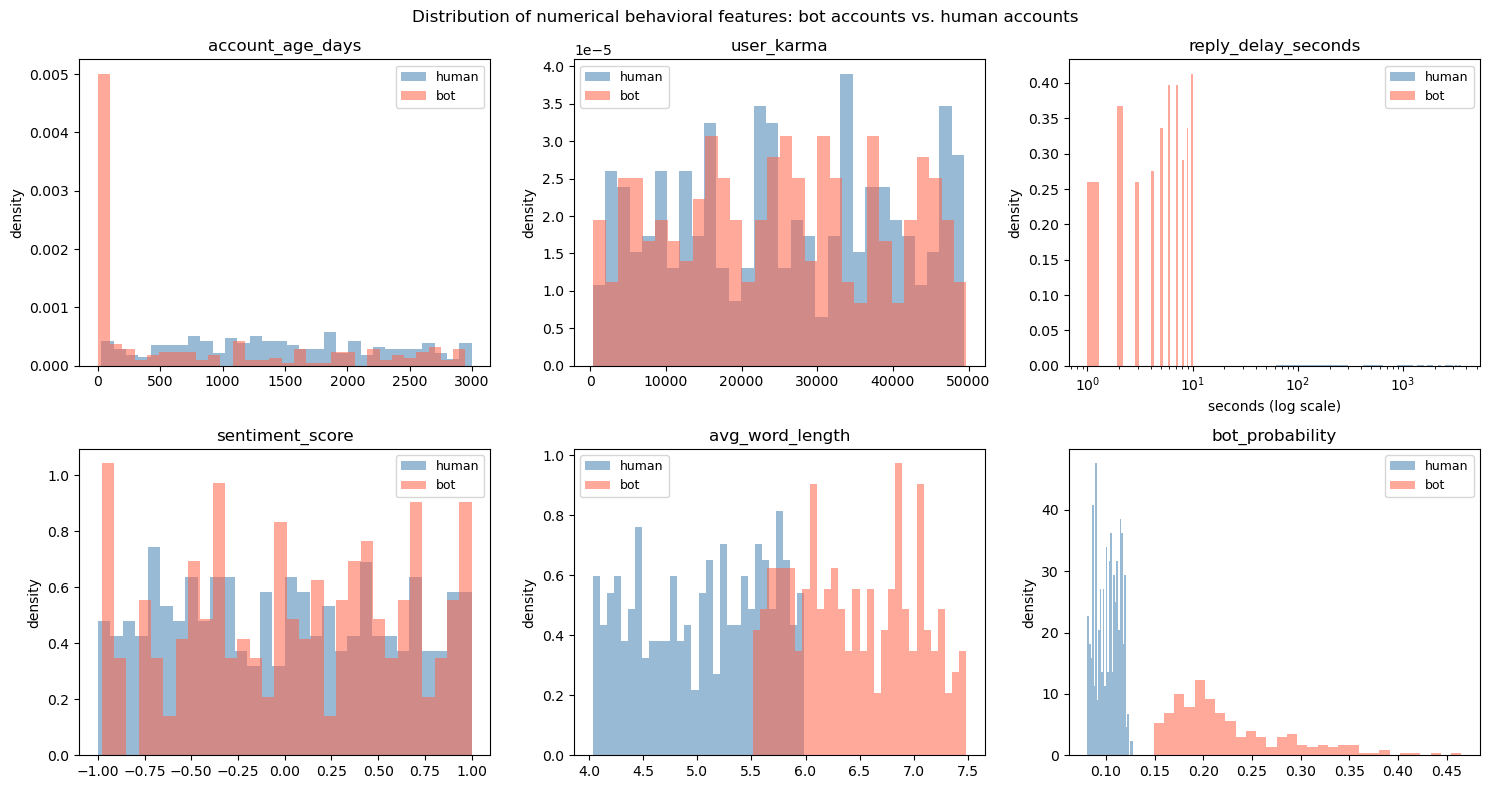

In [109]:
# creating overlapping histograms for each numerical behaviorial feature present in bots and human accounts
fig, axes = plt.subplots(2, 3, figsize = (15, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.hist(humans[col], bins = 30, alpha = .55, color = 'steelblue', 
            label = 'human', density = True)
    ax.hist(bots[col], bins = 30, alpha = .55, color = 'tomato',
            label = 'bot', density = True)
    ax.set_title(col, fontsize = 12)
    ax.set_ylabel('density')
    ax.legend(fontsize = 9)
    
    # log scale for reply_delay_seconds since bots cluster near 0
    
    if col == 'reply_delay_seconds':
        ax.set_xscale('log')
        ax.set_xlabel('seconds (log scale)')
        
fig.suptitle('Distribution of numerical behavioral features: bot accounts vs. human accounts')
plt.tight_layout()
plt.savefig('data/02-processed/bot_vs_humans_behavioral_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

#### The overlapping histograms confirm some strong signals and distribution properties:
- `account_age_days`: The difference in distributions was already suggested by the summary statistics presented earlier in this notebook. Visualizations show that **human accounts have a higher age median and a greater variance**, spanning ~500 to ~3,000 days. In contrast, **bot accounts are right-skewed at low-account ages**, concentrating near <30 days. This pattern is consistent with the expectation that bot-generated accounts are frequently created shortly before being deployed, resulting in relatively young account ages. The large spread observed among human accounts suggests a more heterogeneous population of users with varying levels of platform tenure.

- `reply_delay_seconds`: The distribution of reply delays shows a clear difference in response latency between bots and humans, with **bots responding faster than human users**. Bot accounts show a high density of replies occurring within the first 0–10 seconds after the original comment, producing a sharply left-skewed distribution with a low median response time. In comparison, human accounts display an extremely wider distribution with longer delays and greater variability.

    Meanwhile, because of the widespread of human responses in delay values, the density at any particular time interval is relatively low, making the human distribution less clearly visible in the overlapping histogram. This pattern likely reflects the cognitive and behavioral processes involved in human responses, which require time for reading, comprehension, and message composition. 

    To better illustrate the difference in response latency between bots and humans, we additionally visualize reply_delay_seconds using a boxplot below, which more clearly highlights differences in the median and variability between the two groups. 

- `sentiment_score`: The distribution of sentiment scores indicates that **human comments exhibit greater emotional variability than bots**. Bot-generated comments appear to be more tightly clustered around neutral sentiment values, indicating lower variance in emotional tone. On the other hand, human comments display a wider distribution of sentiment scores, reflecting a broader range of emotional expression in human discourse. This difference may be a result of how bots tend to generate linguistically and emotionally neutral responses to remain contextually appropriate across many scenarios. 

- `avg_word_length`: The distribution of average word length suggest that bot-generated comments **tend to contain longer words** on average compared to human-generated comments. Bots seem to reply with longer average words compared to human accounts, being more left skewed on the histogram compared to humans on the right. This could be due to bots using formal/elaborate vocabulary which was mentioned before in our `Background and Prior Work` section saying that "human user posts contained distinct features such as grammatical discrepancies, internet jargon, and erroneous capitalization, whilst ChatGPT-4 generated texts contained impeccable grammar, a complex syntactical structure, and overused emojis."<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1).

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Arcenal, E. & Capistrano, L. & Guzman, M. & Forrosuelo, M. & Miranda, J. (Sep 2024) Comparative Analysis of Reddit Posts and ChatGPT-Generated Texts’ Linguistic Features: A Short Report on Artificial Intelligence’s Imitative Capabilities. *International Journal of Multidisciplinary: Applied Business and Education*.
https://doi.org/10.11594/ijmaber.05.09.063.

/var/folders/47/9qfh0ynx1tq_zj8xbpspzdqh0000gp/T/ipykernel_56582/2991402043.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=reddit_df, x='account_type', y='reply_delay_seconds', palette= colors)


Text(0.5, 1.0, 'Reply delay by account type')

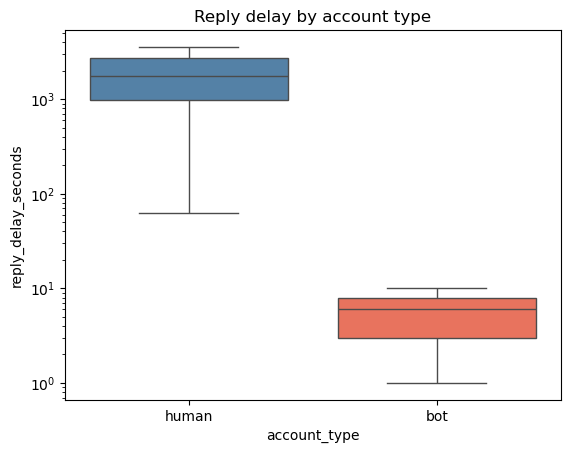

In [151]:
sns.boxplot(data=reddit_df, x='account_type', y='reply_delay_seconds', palette=colors)
plt.yscale('log')
plt.title("Reply delay by account type")

The boxplot **confirms** the pattern suggested by the histogram. Bot accounts reveal a lower median reply delay and a relatively concentrated range, indicating consistently rapid responses. In contrast, human accounts show a higher median delay and a much wider spread of values, reflecting greater variability in response time. This pattern is consistent with the expectation that human users require time to compose replies.

#### Pairplot
While the previous visualizations examine each feature independently, relationships between variables also reveal patterns associated with bot behavior. To explore these interactions, we visualize pairwise relationships between key behavioral variables and `account type` using scatter plots and analyze correlations between features.

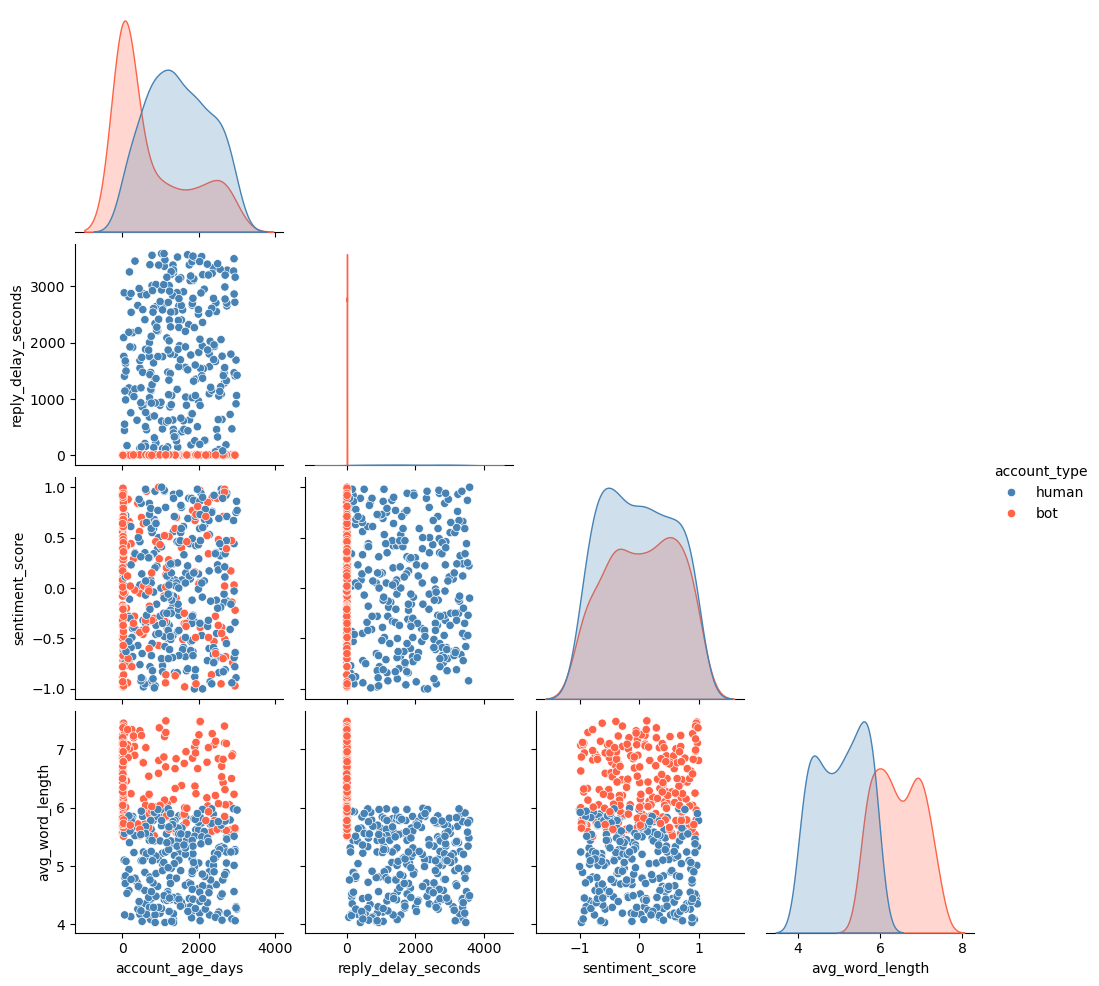

In [135]:
sns.pairplot(reddit_df[['account_age_days','reply_delay_seconds','sentiment_score','avg_word_length','account_type']],hue='account_type',
             palette={'human':'steelblue','bot':'tomato'},corner=True)

#### Correlation matrix of behavioral features and bot probability
Even though `account_type` is the primary variable used to compare bots and humans, we also examine how behavioral features relate to the continuous `bot_probability` score. `bot_probability` is a probabilistic estimate of how likely an account is to exhibit automated behaviorm which allows us to evaluate whether behavioral features change gradually as accounts become more likely to be bots. This helps **validate whether variables** such as account age, reply delay, sentiment score, and linguistic characteristics **are systematically associated with increasing levels of automated activity**.

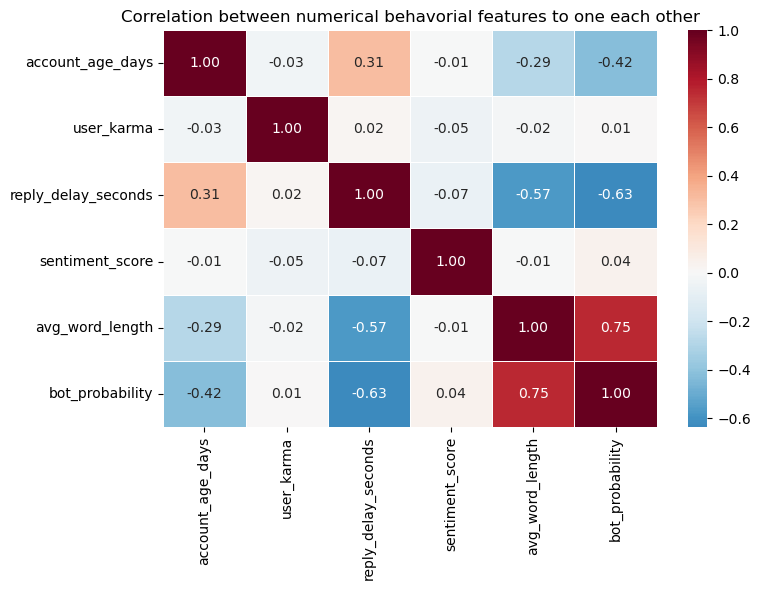

In [31]:
# correlation heatmap 
fig2, ax2 = plt.subplots(figsize = (8, 6))
correlation = reddit_df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation, dtype = bool))
sns.heatmap(correlation, annot = True, fmt = '.2f', cmap = 'RdBu_r', center = 0,linewidths = 0.5, ax = ax2)
ax2.set_title('Correlation between numerical behavorial features to one each other')
plt.tight_layout()
plt.savefig('data/02-processed/behavorial_correlation_heatmap.png', dpi = 120, bbox_inches = 'tight')
plt.show()

Correlation heatmaps reveal that some of our behavioral features do have some correlation with each other.
- `avg_word_length ↔ bot_probability`: With a strong positive correlation score of 0.75, accounts with higher `avg_word_length` tend to have higher `bot_probability` scores. This indicates that accounts replies with longer average words tend to have a higher probability of being classified as bots. This finding aligns with the earlier distribution analysis and supports the hypothesis that bot-generated comments may show more formal language patterns.
  
- `bot_probability ↔ reply_delay_seconds`: A moderately strong negative correlation(-0.63) exists between the `reply_delay_seconds` and `bot probability`. This indicates the faster the reply, the lower the delay, which leads to a higher bot probability. This result is consistent with the earlier observation that bots can respond almost instantaneously, whereas human responses generally take longer time.

- `bot_probability ↔ account_age_days`: A negative correlation(-0.42) is found between `bot probability` and account age, implying that bots are usually newer accounts which leads to a lower account age in days, leading to a higher probability of being a bot.

- `avg_word_length ↔ reply_delay_seconds`: A negative correlation (-0.57) is shown between `avg_word_length` and `reply_delay_seconds`. Bot accounts usually do both in this situation, writing longer words in a short amount of time/lower delayed replies. This pattern is consistent with the hypothesis and reflect AI text-generation processes that can produce relatively complex responses with minimal delay.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics



[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> Reddit's TOS includes that they have the "right for us to make Your Content available for syndication, broadcast, distribution, or publication by other companies, organizations, or individuals who partner with Reddit." While none of our datasets themselves  seem to be Reddit-sponsored or partnered sources, the fact remains that Reddit is a public forum, and most content posted there is public.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> As the data was not collected by us directly, we cannot confirm or deny this. The groups ('subreddits') these data were collected from may be biased in what comments are allowed or visibile in each, based on group culture or rules. Stratifying based on group or group type might help mitigate these biases.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> The data is easily anonymizable by removing account information (names, ids) before performing any analysis.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

> We can test within specific groups in the common scenario that the group's population does not match that of Reddit overall, then compare results relative to the group's population, rather than the population of all data.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

> As the data has already been collected and any identifiable information removed, both concerns are resolved. For the repo specifically, it is protected by both account passwords and SSH keys.
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

> As the data is publically sourced and easily available, there is no reason for us to delete the data after usage. It will remain in the repo for ease of use.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

> We currently have no plans to do this. We also have no plans *not* to do this. Personally, I would like to ask a Reddit engineer or moderator how things are, but I'm unsure if I can get a hold of any.
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> We currently do not see any potential factors of bias in the data after a detailed review. However, such biases are difficult to spot in datasets focused purely on social media messages with lacking information about the life of the people who wrote them.
 - [ ] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> We do not have representations right now. Will revisit after representations are created.
 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

> We can and will remove account ids, names, etc. before the analysis is performed.
 - [ ] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> I sure hope it will be. Will revisit after analysis is complete.

### D. Modeling
> As we currently lack a model, this section will be left blank.
 - [ ] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 - [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [ ] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [ ] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

### E. Deployment
> As we currently lack both a model to deploy and information to disseminate, this section will be left blank.
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [ ] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?


## Team Expectations 

**COMMUNICATION**
* We can expect to communicate regularly through our Instagram group chat and check in with each other regarding progress and deadlines
* If confusion arises, we clear any misunderstandings by asking each other questions as soon as possible

**TONE**
* Firm yet reasonable, well-meaning criticism, and we should recognize that we are all here for the same goal/purpose in this project

**DECISION-MAKING**
* We will take into consideration everyone’s opinions and try to reach some sort of agreement or consensus of opinion when it comes to decisions.
* This can be similar to a group voting system
* We could also have people add to decisions with their ideas instead of it being set in stone

**TASKS AND EXPECTATIONS**
* Communicate precisely and explicitly with each other regarding our division of work and the role that we play transparently, so as not to cause any confusion.
* We will have each member have a specific role that they will fulfill throughout the project, listed at the top of this project proposal.

**CIRCUMSTANCES**
* We will respect each member's differing schedules and workloads as students.
* If in the case of a member not being able to keep up with set deadlines or their part in the project, they should always ask for help as early as possible or notify us when they think so (i.e., they have midterms to focus on at the end of the week)
* We can always have someone help out when needed to lighten the workload 

## Project Timeline Proposal


| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/7  |  5 PM | Gather dataset(s) that will help us answer our research question  | Explain how gathered datasets contribute to the project and answering our research question | 
| 2/11  |  4 PM | Begin collecting background research on our topic | Discuss collected research and begin narrowing down dataset(s) and background research | 
| 2/15  | 5 PM  | Write and edit data descriptions; begin discussing supporting data; look at issues raised from proj proposal  | Communicate data models and purposes in order to formulate proper descriptions; discuss data cleanliness and what needs to be completed before submission   |
| 2/18  | 6 PM  | Finalize datasets and descriptions; Submit Data Checkpoint w/ as much done as possible | Discuss finalization of datasets being used and ensure that the written descriptions provide ample information for their purpose    |
| 2/22  | 4 PM  | Beginning construction of visualization of AI patterns; visualize our findings; correct any errors or shortcomings after review | Discuss types of visualization that will be most effective for our project; disucss fixing areas that are lacking or need improvement  |
| 3/1  | 5 PM  | Continue constructing EDA section; finalize written portion of EDA | Explain written descriptions and context of EDA; clean up information |
| 3/4  | 5 PM  | Complete EDA; Submit EDA Checkpoint | Communicate any final changes necessary for EDA portion of project; begin discussion on finalizing project |
| 3/8  | 4 PM  | Discuss and fix any issues with EDA section and lost points; Write Abstract, Discussion, and Conclusion | Finalize changes on Abstract, Discussion, and Conclusion; discuss repeated areas and analysis further in the context of project overall, ensure everything still makes sense and finalize; finalize fixes from previous sections; discuss video filming and roles for filming  |
| 3/11  | 5 PM  | Film video; Make any final fixes | Discuss any necessary editing; finalize video and discuss end of project  |
| 3/18  | Before 11:59 PM  | Finalize everything | Turn in Final Project, Video, Team Eval Survey, and Post Course Survey |